Import necessary libraries

In [1]:
import os 
import math 
import re 
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer

# for preprocessing and Feature engineering
from sklearn.impute import (
    SimpleImputer,
    KNNImputer
)


from sklearn.feature_selection import(
    SelectKBest,
    SelectPercentile,
    RFE,
    RFECV,
    VarianceThreshold
)

from sklearn.preprocessing import (
    OneHotEncoder,
    MinMaxScaler,
    StandardScaler,
    RobustScaler,
    Normalizer,
    PolynomialFeatures,
    OrdinalEncoder,
    LabelEncoder,
    KBinsDiscretizer
)



# Model Selection and Evaluation

from sklearn.model_selection import (
    train_test_split,
    cross_val_predict,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedKFold,
    KFold,
    cross_validate
)

from sklearn.metrics import (
    accuracy_score,
    precision_recall_curve,
    roc_auc_score,
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    root_mean_squared_error,
    confusion_matrix,
    r2_score,
    classification_report,
    f1_score,
    recall_score,
    explained_variance_score,
    precision_score
)

# For Regression
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet,
    BayesianRidge,
    SGDRegressor,
    PassiveAggressiveRegressor
)

from sklearn.tree import (
    DecisionTreeRegressor,
)

from sklearn.ensemble import (
    
    RandomForestRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor,
    ExtraTreesRegressor,
    BaggingRegressor
)

from sklearn.svm import (
    SVR,
    LinearSVR

)

from sklearn.neighbors import (
    KNeighborsRegressor,
)

from sklearn.neural_network import (
    MLPRegressor,
    _multilayer_perceptron
)


# For Classification
from sklearn.linear_model import (
    LogisticRegression,
    RidgeClassifier,
    Perceptron,
    PassiveAggressiveClassifier,
    SGDClassifier
)

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    ExtraTreesClassifier,
    BaggingClassifier
)

from sklearn.svm import (
    SVC,
    LinearSVC,
    NuSVC
)

from sklearn.neighbors import KNeighborsClassifier

from sklearn.naive_bayes import (
    GaussianNB,
    MultinomialNB,
    BernoulliNB,
    CategoricalNB,
    ComplementNB
)

from sklearn.neural_network import MLPClassifier

from sklearn.discriminant_analysis import (
    QuadraticDiscriminantAnalysis,
    LinearDiscriminantAnalysis
)
from sklearn.impute import IterativeImputer

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import scipy.stats as stats

from scipy.stats import(
anderson,
jarque_bera,
shapiro,
normaltest,
kstest
)
from statsmodels.stats.diagnostic import lilliefors

import category_encoders as ce

from sklearn.feature_extraction import FeatureHasher

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_selection import SelectFromModel
from sklearn.compose import TransformedTargetRegressor


Loading the Data 

In [2]:
path = os.path.join('..', 'data', 'raw', 'used_cars.csv')
df = pd.read_csv(path)

In [3]:
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [4]:
df.memory_usage()

Index             128
brand           32072
model           32072
model_year      32072
milage          32072
fuel_type       32072
engine          32072
transmission    32072
ext_col         32072
int_col         32072
accident        32072
clean_title     32072
price           32072
dtype: int64

In [5]:
## Data clening 


In [6]:
df['price'] = (
    df['price']
    .str.replace("$", "")
    .str.replace(",","")
    .astype(float)
)

In [7]:
df['Engine_Capacity'] = (
    df['engine']
    .str.extract(r'(\d+\.\d+L|\d+\.\d+\s+Liter|d+\s+Liter)')
)

In [8]:
df['Engine_Capacity'] = (
    df['Engine_Capacity']
    .str.replace(" Liter", "")
    .str.replace("L","")
    .astype(float)
)

In [9]:
df['Horse_Power']= (
    df['engine']
    .str.extract(r'(\d+\.\d+HP|\d+HP)')
)

In [10]:
df['Horse_Power'] = (
    df['Horse_Power']
    .str.replace("HP", "")
    .astype(float)
)

In [11]:
df['milage'] = (
    df['milage']
    .str.replace("mi.", "")
    .str.replace(",","")
    .astype(float)
)

In [12]:
df["Accident_occured"] =(
    df['accident'].apply(lambda x: "No" if x == 'None reported' else 'Yes')
)

In [13]:
df[['accident','Accident_occured']].head()

,accident,Accident_occured
0,At least 1 accident or damage reported,Yes
1,At least 1 accident or damage reported,Yes
2,None reported,No
3,None reported,No
4,None reported,No


In [14]:
df.drop(columns= ['accident'], axis=1, inplace =True)

In [15]:
missing_info = {}

for col in df.columns:
    if df[col].isnull().sum()>0:
        missing_count = (df[col].isnull().sum()/len(df))*100
        missing_info[col] = round(missing_count,2)

print('The columns with missing percentage is: \n')

for col,perc in missing_info.items():
    print(f"{col} : {perc}%")

The columns with missing percentage is: 

fuel_type : 4.24%
clean_title : 14.87%
Engine_Capacity : 5.94%
Horse_Power : 20.15%


In [16]:
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,clean_title,price,Engine_Capacity,Horse_Power,Accident_occured
0,Ford,Utility Police Interceptor Base,2013,51000.0,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,Yes,10300.0,3.7,300.0,Yes
1,Hyundai,Palisade SEL,2021,34742.0,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,Yes,38005.0,3.8,NaN,Yes
2,Lexus,RX 350 RX 350,2022,22372.0,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,NaN,54598.0,3.5,NaN,No
3,INFINITI,Q50 Hybrid Sport,2015,88900.0,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,Yes,15500.0,3.5,354.0,No
4,Audi,Q3 45 S line Premium Plus,2021,9835.0,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,NaN,34999.0,2.0,NaN,No


In [17]:
df['brand'].value_counts()

brand
Ford             386
BMW              375
Mercedes-Benz    315
Chevrolet        292
Porsche          201
Audi             200
Toyota           199
Lexus            163
Jeep             143
Land             130
Nissan           116
Cadillac         107
GMC               91
RAM               91
Dodge             90
Tesla             87
Kia               76
Hyundai           72
Subaru            64
Acura             64
Mazda             64
Honda             63
INFINITI          59
Volkswagen        59
Lincoln           52
Jaguar            47
Volvo             38
Maserati          34
Bentley           33
MINI              33
Buick             30
Chrysler          28
Lamborghini       26
Genesis           20
Mitsubishi        20
Alfa              19
Rivian            17
Hummer            16
Pontiac           15
Ferrari           12
Rolls-Royce       11
Aston              9
Scion              6
McLaren            6
Saturn             5
FIAT               5
Lotus              4
Lucid  

In [18]:
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,clean_title,price,Engine_Capacity,Horse_Power,Accident_occured
0,Ford,Utility Police Interceptor Base,2013,51000.0,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,Yes,10300.0,3.7,300.0,Yes
1,Hyundai,Palisade SEL,2021,34742.0,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,Yes,38005.0,3.8,NaN,Yes
2,Lexus,RX 350 RX 350,2022,22372.0,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,NaN,54598.0,3.5,NaN,No
3,INFINITI,Q50 Hybrid Sport,2015,88900.0,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,Yes,15500.0,3.5,354.0,No
4,Audi,Q3 45 S line Premium Plus,2021,9835.0,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,NaN,34999.0,2.0,NaN,No


In [19]:
df['brand'].value_counts()

brand
Ford             386
BMW              375
Mercedes-Benz    315
Chevrolet        292
Porsche          201
Audi             200
Toyota           199
Lexus            163
Jeep             143
Land             130
Nissan           116
Cadillac         107
GMC               91
RAM               91
Dodge             90
Tesla             87
Kia               76
Hyundai           72
Subaru            64
Acura             64
Mazda             64
Honda             63
INFINITI          59
Volkswagen        59
Lincoln           52
Jaguar            47
Volvo             38
Maserati          34
Bentley           33
MINI              33
Buick             30
Chrysler          28
Lamborghini       26
Genesis           20
Mitsubishi        20
Alfa              19
Rivian            17
Hummer            16
Pontiac           15
Ferrari           12
Rolls-Royce       11
Aston              9
Scion              6
McLaren            6
Saturn             5
FIAT               5
Lotus              4
Lucid  

In [20]:
brand_counts = df['brand'].value_counts()


In [21]:
#valid_brands = brand_counts[brand_counts >= 10].index


In [22]:
#df = df[df['brand'].isin(valid_brands)]


In [23]:
#df['brand'].value_counts()

In [24]:
df.head(100)
df.tail(100)


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,clean_title,price,Engine_Capacity,Horse_Power,Accident_occured
3909,Buick,Cascada Base,2016,103814.0,Gasoline,200.0HP 1.6L 4 Cylinder Engine Gasoline Fuel,6-Speed A/T,White,Black,Yes,14995.0,1.6,200.0,Yes
3910,Toyota,4Runner Venture,2021,27000.0,Gasoline,270.0HP 4.0L V6 Cylinder Engine Gasoline Fuel,A/T,White,Black,Yes,48500.0,4.0,270.0,No
3911,BMW,530 i xDrive,2021,60942.0,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier Silver Metallic,Black,Yes,32085.0,2.0,NaN,No
3912,BMW,535 i xDrive,2011,100780.0,Gasoline,300.0HP 3.0L Straight 6 Cylinder Engine Gasoli...,8-Speed A/T,Gray,Black,Yes,12000.0,3.0,300.0,Yes
3913,Tesla,Model S 100D,2018,65000.0,NaN,518.0HP Electric Motor Electric Fuel System,A/T,Blue,Black,Yes,41000.0,NaN,518.0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4004,Bentley,Continental GT Speed,2023,714.0,Gasoline,6.0L W12 48V PDI DOHC Twin Turbo,8-Speed Automatic with Auto-Shift,C / C,Hotspur,Yes,349950.0,6.0,NaN,No
4005,Audi,S4 3.0T Premium Plus,2022,10900.0,Gasoline,349.0HP 3.0L V6 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,Yes,53900.0,3.0,349.0,No
4006,Porsche,Taycan,2022,2116.0,NaN,Electric,Automatic,Black,Black,NaN,90998.0,NaN,NaN,No
4007,Ford,F-150 Raptor,2020,33000.0,Gasoline,450.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,A/T,Blue,Black,Yes,62999.0,3.5,450.0,No


In [25]:
Numerical_Columns=df.select_dtypes(include=['number','int32','int64','float32','float64']).columns
categorical_Columns=df.select_dtypes(include=['object','category']).columns



In [26]:
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,clean_title,price,Engine_Capacity,Horse_Power,Accident_occured
0,Ford,Utility Police Interceptor Base,2013,51000.0,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,Yes,10300.0,3.7,300.0,Yes
1,Hyundai,Palisade SEL,2021,34742.0,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,Yes,38005.0,3.8,NaN,Yes
2,Lexus,RX 350 RX 350,2022,22372.0,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,NaN,54598.0,3.5,NaN,No
3,INFINITI,Q50 Hybrid Sport,2015,88900.0,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,Yes,15500.0,3.5,354.0,No
4,Audi,Q3 45 S line Premium Plus,2021,9835.0,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,NaN,34999.0,2.0,NaN,No


In [27]:
missing_info={}
for col in Numerical_Columns:
    if df[col].isnull().sum()>0:
        missing_count=(df[col].isnull().sum()/len(df))*100
        missing_info[col]=round(missing_count,3)

print("\nNumerical columns with missing percentage is:\n")
for col, perc in missing_info.items():
    print(f'{col} : {perc}%')


Numerical columns with missing percentage is:

Engine_Capacity : 5.937%
Horse_Power : 20.155%


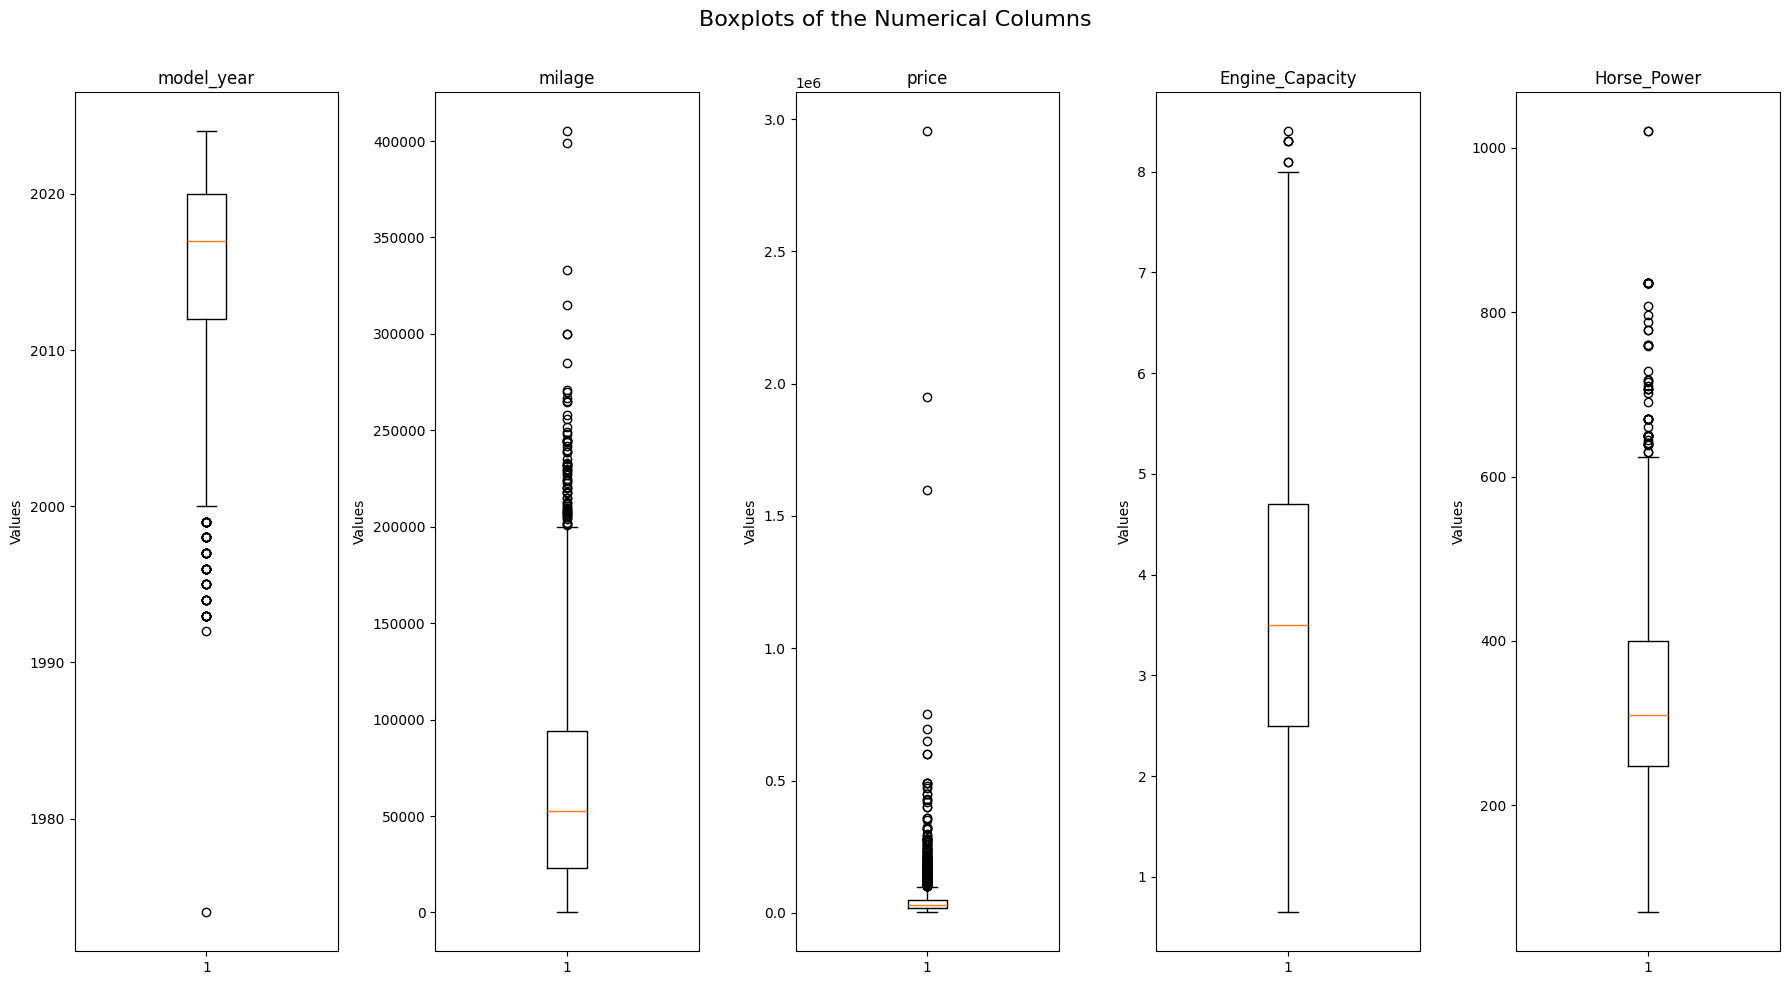

In [28]:
import matplotlib.pyplot as plt


fig, axes = plt.subplots(1, 5, figsize=(18, 10))  # 1 row, 5 columns

for i, col in enumerate(Numerical_Columns):
    axes[i].boxplot(df[col].dropna())      # Drop NaNs
    axes[i].set_title(col, fontsize=12)
    axes[i].set_ylabel("Values", fontsize=10)

plt.suptitle("Boxplots of the Numerical Columns", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])  # leave space for suptitle
plt.show()


In [29]:
df[df['Engine_Capacity'].isnull()][['brand','Engine_Capacity']]

,brand,Engine_Capacity
9,Tesla,NaN
10,Land,NaN
32,BMW,NaN
44,Lucid,NaN
68,Lucid,NaN
...,...,...
3932,Tesla,NaN
3952,Dodge,NaN
3961,Tesla,NaN
3984,Toyota,NaN


In [30]:
df.head()



,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,clean_title,price,Engine_Capacity,Horse_Power,Accident_occured
0,Ford,Utility Police Interceptor Base,2013,51000.0,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,Yes,10300.0,3.7,300.0,Yes
1,Hyundai,Palisade SEL,2021,34742.0,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,Yes,38005.0,3.8,NaN,Yes
2,Lexus,RX 350 RX 350,2022,22372.0,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,NaN,54598.0,3.5,NaN,No
3,INFINITI,Q50 Hybrid Sport,2015,88900.0,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,Yes,15500.0,3.5,354.0,No
4,Audi,Q3 45 S line Premium Plus,2021,9835.0,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,NaN,34999.0,2.0,NaN,No


In [31]:
pd.set_option('display.max_rows',None)
pd.set_option('display.max_columns',None)
pd.set_option('display.max_colwidth',None)

In [32]:
print(df.to_string())


              brand                                                    model  model_year    milage       fuel_type                                                                 engine                                                      transmission                                  ext_col                     int_col clean_title      price  Engine_Capacity  Horse_Power Accident_occured
0              Ford                          Utility Police Interceptor Base        2013   51000.0   E85 Flex Fuel                   300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capability                                                       6-Speed A/T                                    Black                       Black         Yes    10300.0             3.70        300.0              Yes
1           Hyundai                                             Palisade SEL        2021   34742.0        Gasoline                                                   3.8L V6 24V GDI DOHC                                 

In [33]:
df['Engine_Capacity_Missing']=df['Engine_Capacity'].isna().astype(int)

In [34]:
df.loc[df['engine'].str.contains('Electric Fuel System',case=False,na=False),'Engine_Capacity']=0

In [35]:
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,clean_title,price,Engine_Capacity,Horse_Power,Accident_occured,Engine_Capacity_Missing
0,Ford,Utility Police Interceptor Base,2013,51000.0,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capability,6-Speed A/T,Black,Black,Yes,10300.0,3.7,300.0,Yes,0
1,Hyundai,Palisade SEL,2021,34742.0,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,Yes,38005.0,3.8,NaN,Yes,0
2,Lexus,RX 350 RX 350,2022,22372.0,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,NaN,54598.0,3.5,NaN,No,0
3,INFINITI,Q50 Hybrid Sport,2015,88900.0,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric Hybrid,7-Speed A/T,Black,Black,Yes,15500.0,3.5,354.0,No,0
4,Audi,Q3 45 S line Premium Plus,2021,9835.0,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,NaN,34999.0,2.0,NaN,No,0


In [36]:
pd.set_option('display.max_rows',None)
pd.set_option('display.max_columns',None)
pd.set_option('display.max_colwidth',None)
df.loc[df['Engine_Capacity'].isnull(),['Engine_Capacity','engine']]

,Engine_Capacity,engine
10,NaN,V6
32,NaN,120 AH
120,NaN,V6
130,NaN,–
236,NaN,Electric
257,NaN,–
321,NaN,Electric
326,NaN,"AMG 3L I-6 gasoline direct injection, DOHC, variable valve contr"
338,NaN,–
383,NaN,Standard Range Battery


In [37]:
df['Engine_Capacity']=df['Engine_Capacity'].where(~df['engine'].str.contains('Electric Motor Electric Fuel System',case=False,na=False),df['Engine_Capacity'].fillna(0))

In [38]:
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,clean_title,price,Engine_Capacity,Horse_Power,Accident_occured,Engine_Capacity_Missing
0,Ford,Utility Police Interceptor Base,2013,51000.0,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capability,6-Speed A/T,Black,Black,Yes,10300.0,3.7,300.0,Yes,0
1,Hyundai,Palisade SEL,2021,34742.0,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,Yes,38005.0,3.8,NaN,Yes,0
2,Lexus,RX 350 RX 350,2022,22372.0,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,NaN,54598.0,3.5,NaN,No,0
3,INFINITI,Q50 Hybrid Sport,2015,88900.0,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric Hybrid,7-Speed A/T,Black,Black,Yes,15500.0,3.5,354.0,No,0
4,Audi,Q3 45 S line Premium Plus,2021,9835.0,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,NaN,34999.0,2.0,NaN,No,0


In [39]:
df.loc[df['Engine_Capacity'].isnull(),['Engine_Capacity','engine','brand','fuel_type','model']]

,Engine_Capacity,engine,brand,fuel_type,model
10,NaN,V6,Land,Gasoline,Rover Range Rover Sport 3.0 Supercharged HST
32,NaN,120 AH,BMW,Hybrid,i3 120Ah w/Range Extender
120,NaN,V6,Land,Gasoline,Rover Range Rover Sport 3.0L Supercharged HSE
130,NaN,–,Chrysler,–,Pacifica Touring
236,NaN,Electric,Polestar,NaN,2 Launch Edition
257,NaN,–,Toyota,–,Land Cruiser Base
321,NaN,Electric,Chevrolet,NaN,Bolt EUV Premier
326,NaN,"AMG 3L I-6 gasoline direct injection, DOHC, variable valve contr",Mercedes-Benz,Gasoline,AMG E 53 4MATIC
338,NaN,–,Mazda,–,Mazda3 s Grand Touring
383,NaN,Standard Range Battery,Ford,NaN,Mustang Mach-E Select


In [40]:
df.loc[df['engine'].str.contains('Electric Motor Electric Fuel System',case=False,na=False),['Engine_Capacity','engine','brand','fuel_type']]

,Engine_Capacity,engine,brand,fuel_type
9,0.0,534.0HP Electric Motor Electric Fuel System,Tesla,NaN
44,0.0,536.0HP Electric Motor Electric Fuel System,Lucid,NaN
68,0.0,536.0HP Electric Motor Electric Fuel System,Lucid,NaN
92,0.0,835.0HP Electric Motor Electric Fuel System,Rivian,NaN
122,0.0,835.0HP Electric Motor Electric Fuel System,Rivian,NaN
129,0.0,620.0HP Electric Motor Electric Fuel System,Lucid,NaN
155,0.0,455.0HP Electric Motor Electric Fuel System,Tesla,NaN
189,0.0,455.0HP Electric Motor Electric Fuel System,Tesla,NaN
225,0.0,670.0HP Electric Motor Electric Fuel System,Tesla,NaN
253,0.0,355.0HP Electric Motor Electric Fuel System,Mercedes-Benz,NaN


In [41]:
df['Engine_Capacity']=df['Engine_Capacity'].where(~df['engine'].str.contains('Electric',case=False,na=False),df['Engine_Capacity'].fillna(0))

In [42]:
df.loc[df['Engine_Capacity'].isnull(),['Engine_Capacity','engine','brand','fuel_type','model']]

,Engine_Capacity,engine,brand,fuel_type,model
10,NaN,V6,Land,Gasoline,Rover Range Rover Sport 3.0 Supercharged HST
32,NaN,120 AH,BMW,Hybrid,i3 120Ah w/Range Extender
120,NaN,V6,Land,Gasoline,Rover Range Rover Sport 3.0L Supercharged HSE
130,NaN,–,Chrysler,–,Pacifica Touring
257,NaN,–,Toyota,–,Land Cruiser Base
326,NaN,"AMG 3L I-6 gasoline direct injection, DOHC, variable valve contr",Mercedes-Benz,Gasoline,AMG E 53 4MATIC
338,NaN,–,Mazda,–,Mazda3 s Grand Touring
383,NaN,Standard Range Battery,Ford,NaN,Mustang Mach-E Select
456,NaN,111.2Ah / FR 70kW / RR 160kW (697V),Kia,NaN,EV6 Wind
491,NaN,–,Chrysler,–,Pacifica Touring


In [43]:
df['Engine_Capacity']=df['Engine_Capacity'].where(~df['engine'].str.contains('Dual Motor - Standard',case=False,na=False),df['Engine_Capacity'].fillna(0))

In [44]:
df.loc[df['Engine_Capacity'].isnull(),['Engine_Capacity','engine','brand','fuel_type','model']]

,Engine_Capacity,engine,brand,fuel_type,model
10,NaN,V6,Land,Gasoline,Rover Range Rover Sport 3.0 Supercharged HST
32,NaN,120 AH,BMW,Hybrid,i3 120Ah w/Range Extender
120,NaN,V6,Land,Gasoline,Rover Range Rover Sport 3.0L Supercharged HSE
130,NaN,–,Chrysler,–,Pacifica Touring
257,NaN,–,Toyota,–,Land Cruiser Base
326,NaN,"AMG 3L I-6 gasoline direct injection, DOHC, variable valve contr",Mercedes-Benz,Gasoline,AMG E 53 4MATIC
338,NaN,–,Mazda,–,Mazda3 s Grand Touring
383,NaN,Standard Range Battery,Ford,NaN,Mustang Mach-E Select
456,NaN,111.2Ah / FR 70kW / RR 160kW (697V),Kia,NaN,EV6 Wind
491,NaN,–,Chrysler,–,Pacifica Touring


In [45]:
print(f"Missing percentage in the Engine_capacity is: {round(df['Engine_Capacity'].isna().sum() / len(df) * 100, 2)} %")


Missing percentage in the Engine_capacity is: 1.85 %


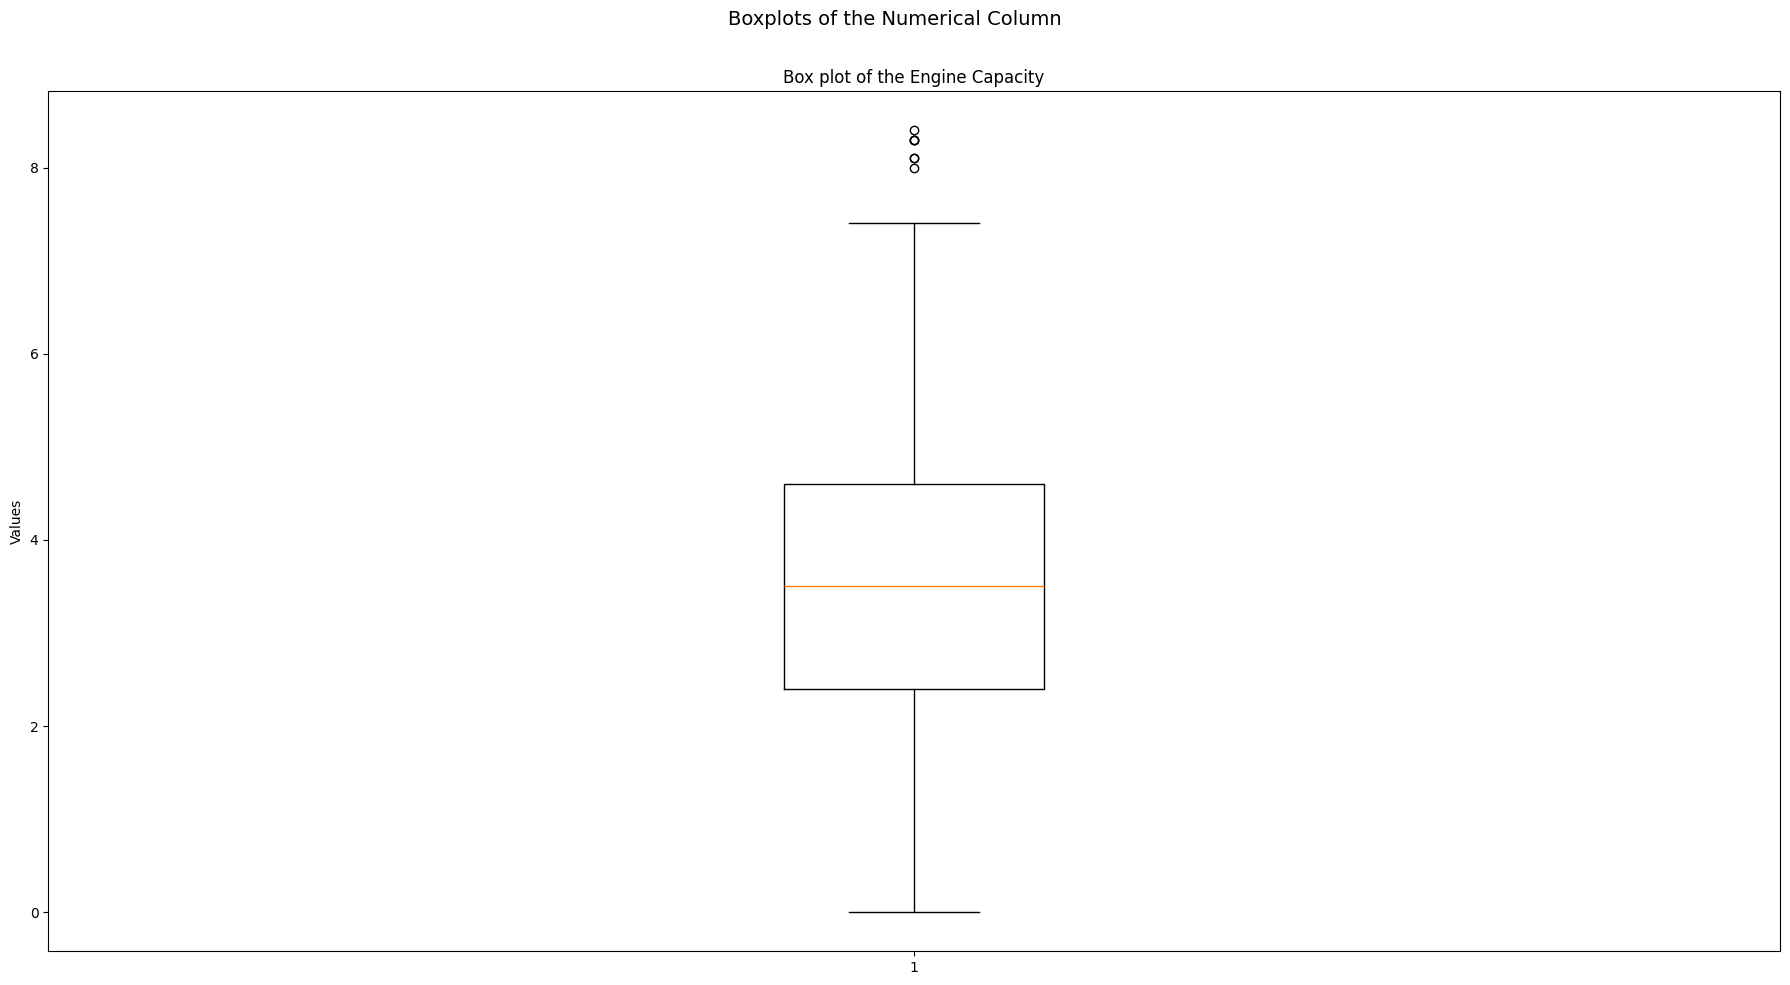

In [46]:
fig,axes=plt.subplots(figsize=(18,10))
axes.boxplot(df['Engine_Capacity'].dropna())
axes.set_title("Box plot of the Engine Capacity")
axes.set_ylabel("Values")
plt.suptitle("Boxplots of the Numerical Column",fontsize=14)
plt.tight_layout(rect=[0,0,1,0.97])
plt.show()

In [47]:
df['Engine_Capacity']=df['Engine_Capacity'].fillna(df['Engine_Capacity'].median())

In [48]:
df.loc[df['Engine_Capacity'].isnull(),['Engine_Capacity','engine','brand','fuel_type','model']]

,Engine_Capacity,engine,brand,fuel_type,model


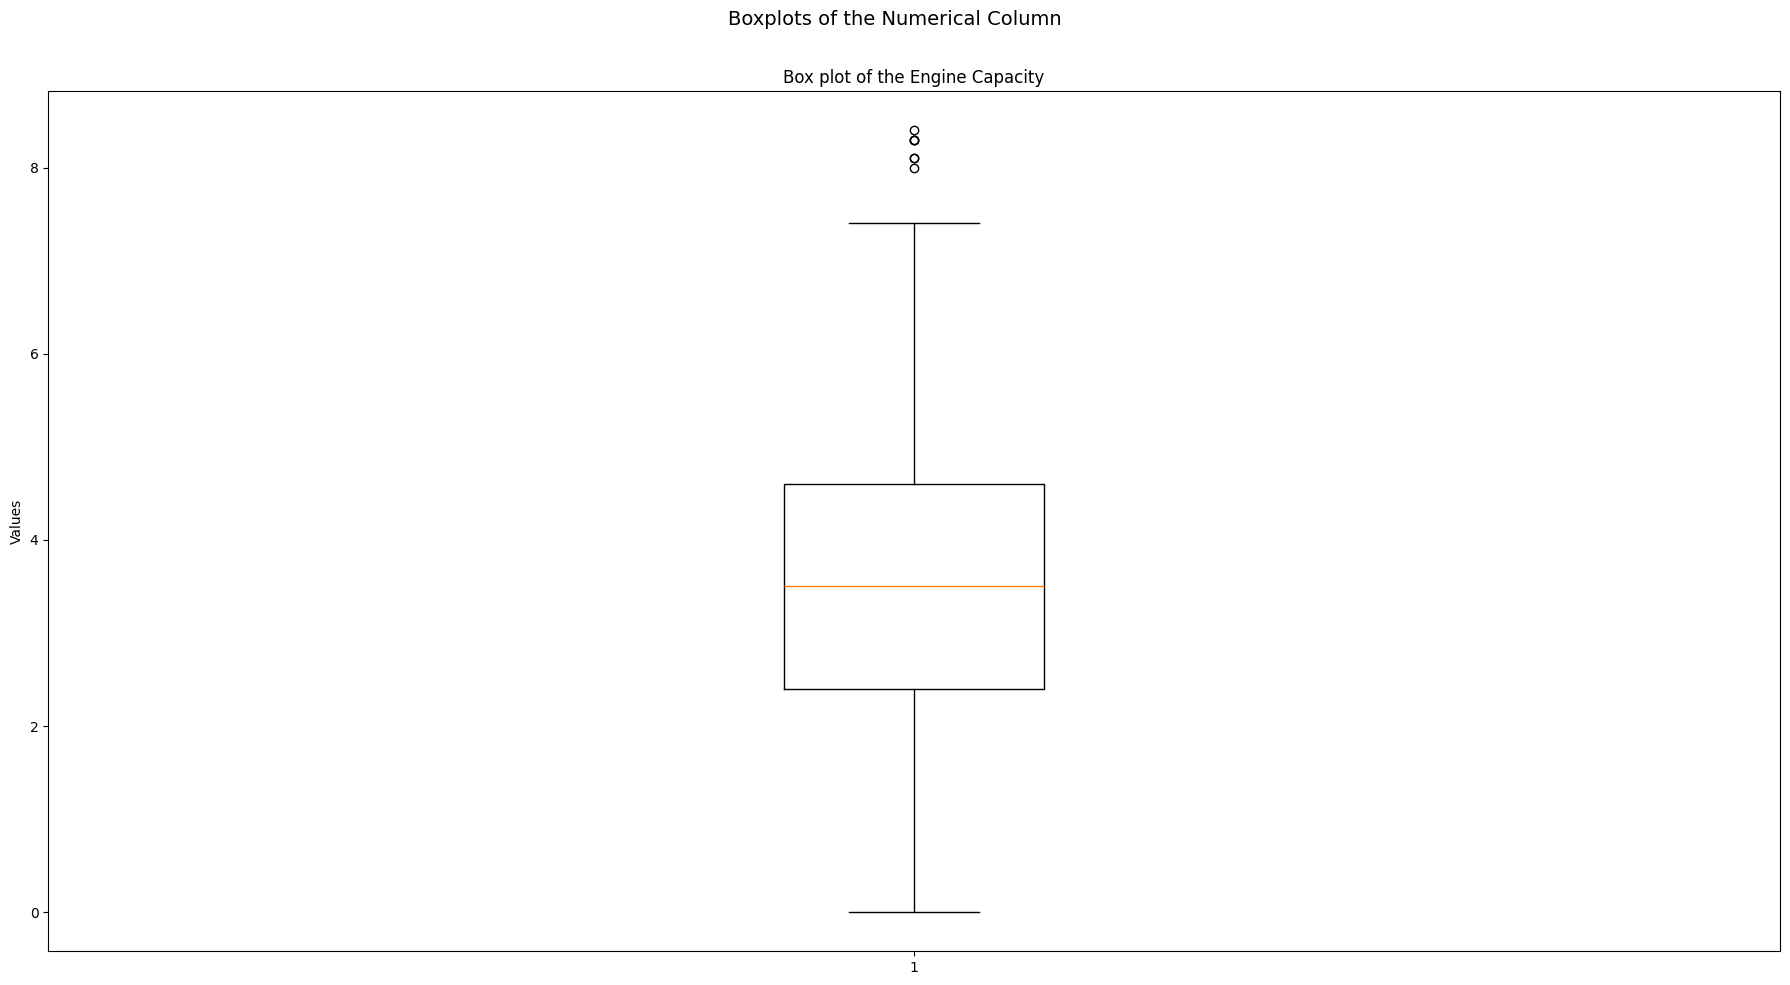

In [49]:
fig,axes=plt.subplots(figsize=(18,10))
axes.boxplot(df['Engine_Capacity'].dropna())
axes.set_title("Box plot of the Engine Capacity")
axes.set_ylabel("Values")
plt.suptitle("Boxplots of the Numerical Column",fontsize=14)
plt.tight_layout(rect=[0,0,1,0.97])
plt.show()

In [50]:
print(f"Missing percentage in the Engine_capacity is: {round(df['Engine_Capacity'].isna().sum() / len(df) * 100, 2)} %")


Missing percentage in the Engine_capacity is: 0.0 %


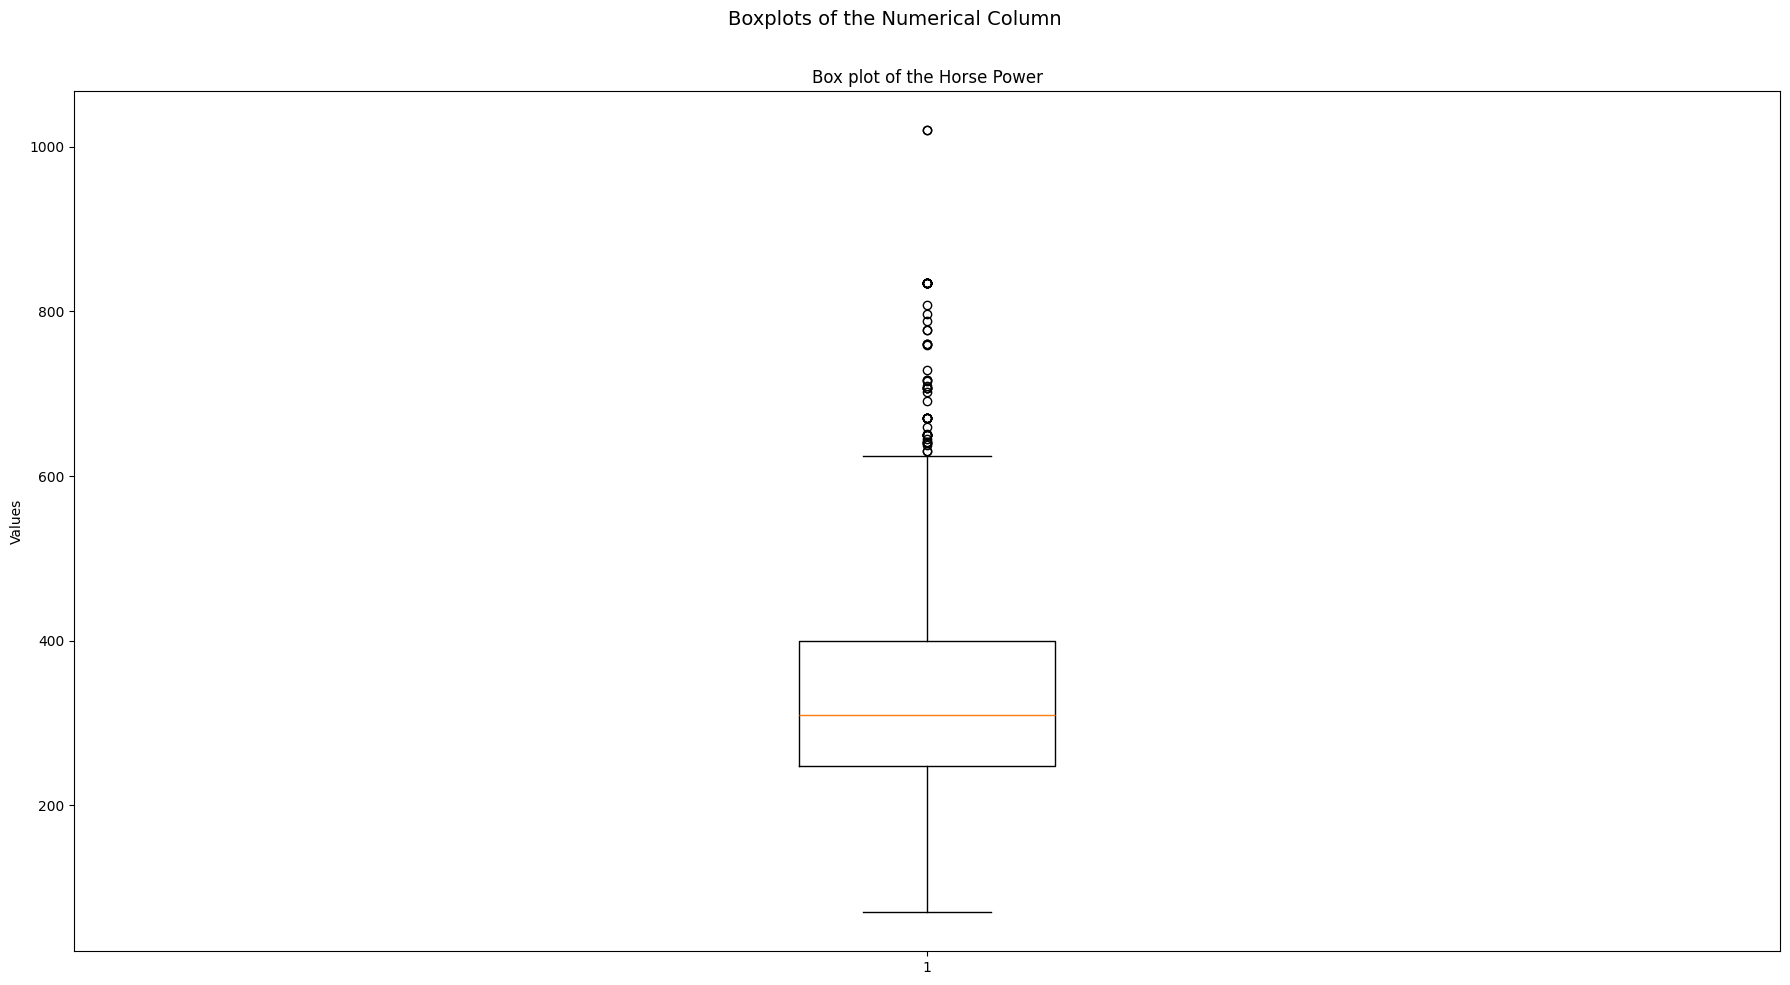

In [51]:
fig,axes=plt.subplots(figsize=(18,10))
axes.boxplot(df['Horse_Power'].dropna())
axes.set_title("Box plot of the Horse Power")
axes.set_ylabel("Values")
plt.suptitle("Boxplots of the Numerical Column",fontsize=14)
plt.tight_layout(rect=[0,0,1,0.97])
plt.show()

In [52]:
skew_value=df['Horse_Power'].skew()
print(f'The skewness of the Horse Power is: {skew_value:.3f}')

The skewness of the Horse Power is: 0.947


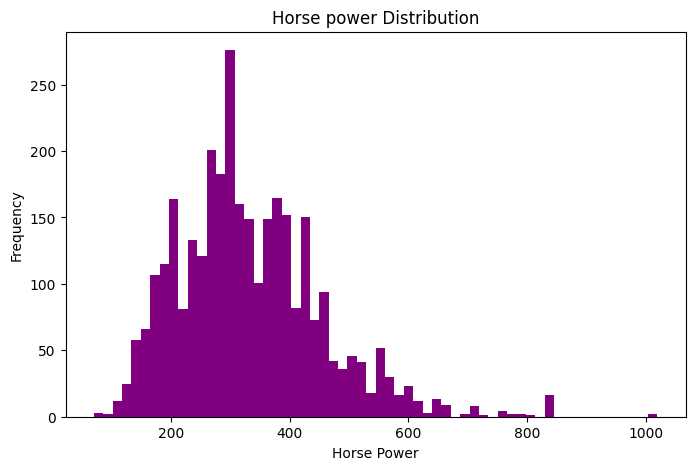

In [53]:
fig,axes=plt.subplots(figsize=(8,5))
axes.hist(df['Horse_Power'].dropna(),bins=60,color='purple')
axes.set_title('Horse power Distribution')
axes.set_xlabel("Horse Power")
axes.set_ylabel("Frequency")
plt.show()

In [54]:


numeric_cols=['Engine_Capacity','model_year','milage','Horse_Power','price']
df[numeric_cols]=df[numeric_cols].apply(pd.to_numeric, errors='coerce')

known=df[df['Horse_Power'].notna()]
missing=df[df['Horse_Power'].isna()]


numerical_features=['Engine_Capacity','model_year','milage','price']
categorical_features=['brand']

preprocessor=ColumnTransformer(
    transformers=[
        ('cat',OneHotEncoder(handle_unknown='ignore'),categorical_features)
    ],
    remainder='passthrough'
)

pipeline=Pipeline(steps=[
    ('preprocessors',preprocessor),
    ('regressor',LinearRegression())
])

pipeline.fit(
    known[categorical_features+numerical_features],
    known['Horse_Power']
)

predicted_horsepower=pipeline.predict(missing[categorical_features+numerical_features])

df.loc[df['Horse_Power'].isna(),'Horse_Power']=predicted_horsepower

df['Horse_Power']=df['Horse_Power'].clip(lower=0)

print("All the missing values are filled with the linear regression impuatation technique.")

All the missing values are filled with the linear regression impuatation technique.


In [55]:
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,clean_title,price,Engine_Capacity,Horse_Power,Accident_occured,Engine_Capacity_Missing
0,Ford,Utility Police Interceptor Base,2013,51000.0,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capability,6-Speed A/T,Black,Black,Yes,10300.0,3.7,300.000000,Yes,0
1,Hyundai,Palisade SEL,2021,34742.0,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,Yes,38005.0,3.8,386.196279,Yes,0
2,Lexus,RX 350 RX 350,2022,22372.0,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,NaN,54598.0,3.5,392.446701,No,0
3,INFINITI,Q50 Hybrid Sport,2015,88900.0,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric Hybrid,7-Speed A/T,Black,Black,Yes,15500.0,3.5,354.000000,No,0
4,Audi,Q3 45 S line Premium Plus,2021,9835.0,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,NaN,34999.0,2.0,334.561453,No,0


In [56]:
df.head(100)

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,clean_title,price,Engine_Capacity,Horse_Power,Accident_occured,Engine_Capacity_Missing
0,Ford,Utility Police Interceptor Base,2013,51000.0,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capability,6-Speed A/T,Black,Black,Yes,10300.0,3.7,300.000000,Yes,0
1,Hyundai,Palisade SEL,2021,34742.0,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,Yes,38005.0,3.8,386.196279,Yes,0
2,Lexus,RX 350 RX 350,2022,22372.0,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,NaN,54598.0,3.5,392.446701,No,0
3,INFINITI,Q50 Hybrid Sport,2015,88900.0,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric Hybrid,7-Speed A/T,Black,Black,Yes,15500.0,3.5,354.000000,No,0
4,Audi,Q3 45 S line Premium Plus,2021,9835.0,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,NaN,34999.0,2.0,334.561453,No,0
5,Acura,ILX 2.4L,2016,136397.0,Gasoline,2.4 Liter,F,Silver,Ebony.,NaN,14798.0,2.4,255.748736,No,0
6,Audi,S3 2.0T Premium Plus,2017,84000.0,Gasoline,292.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,6-Speed A/T,Blue,Black,Yes,31000.0,2.0,292.000000,No,0
7,BMW,740 iL,2001,242000.0,Gasoline,282.0HP 4.4L 8 Cylinder Engine Gasoline Fuel,A/T,Green,Green,Yes,7300.0,4.4,282.000000,No,0
8,Lexus,RC 350 F Sport,2021,23436.0,Gasoline,311.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,6-Speed A/T,Black,Black,Yes,41927.0,3.5,311.000000,No,0
9,Tesla,Model X Long Range Plus,2020,34000.0,NaN,534.0HP Electric Motor Electric Fuel System,A/T,Black,Black,Yes,69950.0,0.0,534.000000,No,1


In [57]:
df['clean_title']=df['clean_title'].fillna('unknown')

In [58]:
df.head(20)

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,clean_title,price,Engine_Capacity,Horse_Power,Accident_occured,Engine_Capacity_Missing
0,Ford,Utility Police Interceptor Base,2013,51000.0,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capability,6-Speed A/T,Black,Black,Yes,10300.0,3.7,300.000000,Yes,0
1,Hyundai,Palisade SEL,2021,34742.0,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,Yes,38005.0,3.8,386.196279,Yes,0
2,Lexus,RX 350 RX 350,2022,22372.0,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,unknown,54598.0,3.5,392.446701,No,0
3,INFINITI,Q50 Hybrid Sport,2015,88900.0,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric Hybrid,7-Speed A/T,Black,Black,Yes,15500.0,3.5,354.000000,No,0
4,Audi,Q3 45 S line Premium Plus,2021,9835.0,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,unknown,34999.0,2.0,334.561453,No,0
5,Acura,ILX 2.4L,2016,136397.0,Gasoline,2.4 Liter,F,Silver,Ebony.,unknown,14798.0,2.4,255.748736,No,0
6,Audi,S3 2.0T Premium Plus,2017,84000.0,Gasoline,292.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,6-Speed A/T,Blue,Black,Yes,31000.0,2.0,292.000000,No,0
7,BMW,740 iL,2001,242000.0,Gasoline,282.0HP 4.4L 8 Cylinder Engine Gasoline Fuel,A/T,Green,Green,Yes,7300.0,4.4,282.000000,No,0
8,Lexus,RC 350 F Sport,2021,23436.0,Gasoline,311.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,6-Speed A/T,Black,Black,Yes,41927.0,3.5,311.000000,No,0
9,Tesla,Model X Long Range Plus,2020,34000.0,NaN,534.0HP Electric Motor Electric Fuel System,A/T,Black,Black,Yes,69950.0,0.0,534.000000,No,1


In [59]:
pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',None)
pd.set_option('display.max_colwidth',None)
df.loc[df['fuel_type'].isna(),['fuel_type','engine','transmission']]

,fuel_type,engine,transmission
9,NaN,534.0HP Electric Motor Electric Fuel System,A/T
44,NaN,536.0HP Electric Motor Electric Fuel System,1-Speed A/T
68,NaN,536.0HP Electric Motor Electric Fuel System,1-Speed A/T
92,NaN,835.0HP Electric Motor Electric Fuel System,1-Speed A/T
122,NaN,835.0HP Electric Motor Electric Fuel System,A/T
129,NaN,620.0HP Electric Motor Electric Fuel System,A/T
155,NaN,455.0HP Electric Motor Electric Fuel System,A/T
189,NaN,455.0HP Electric Motor Electric Fuel System,1-Speed A/T
225,NaN,670.0HP Electric Motor Electric Fuel System,A/T
236,NaN,Electric,1-Speed Automatic


In [60]:
df.loc[
    df['fuel_type'].isna()&df['engine']
    .str.contains(
        'Electric Motor Electric Fuel System|Electric|Dual Motor - Standard|Battery Electric|Standard Range Battery',case=False,na=False),'fuel_type']='Electric'


In [61]:
df['fuel_type']=df['fuel_type'].fillna('Electric')

In [62]:
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,clean_title,price,Engine_Capacity,Horse_Power,Accident_occured,Engine_Capacity_Missing
0,Ford,Utility Police Interceptor Base,2013,51000.0,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capability,6-Speed A/T,Black,Black,Yes,10300.0,3.7,300.000000,Yes,0
1,Hyundai,Palisade SEL,2021,34742.0,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,Yes,38005.0,3.8,386.196279,Yes,0
2,Lexus,RX 350 RX 350,2022,22372.0,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,unknown,54598.0,3.5,392.446701,No,0
3,INFINITI,Q50 Hybrid Sport,2015,88900.0,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric Hybrid,7-Speed A/T,Black,Black,Yes,15500.0,3.5,354.000000,No,0
4,Audi,Q3 45 S line Premium Plus,2021,9835.0,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,unknown,34999.0,2.0,334.561453,No,0


In [63]:
df.isnull().sum()

brand                      0
model                      0
model_year                 0
milage                     0
fuel_type                  0
engine                     0
transmission               0
ext_col                    0
int_col                    0
clean_title                0
price                      0
Engine_Capacity            0
Horse_Power                0
Accident_occured           0
Engine_Capacity_Missing    0
dtype: int64

## procedure to remove outliers form the Numerical columns(if necessary)

In [64]:
Numerical_Columns

Index(['model_year', 'milage', 'price', 'Engine_Capacity', 'Horse_Power'], dtype='object')

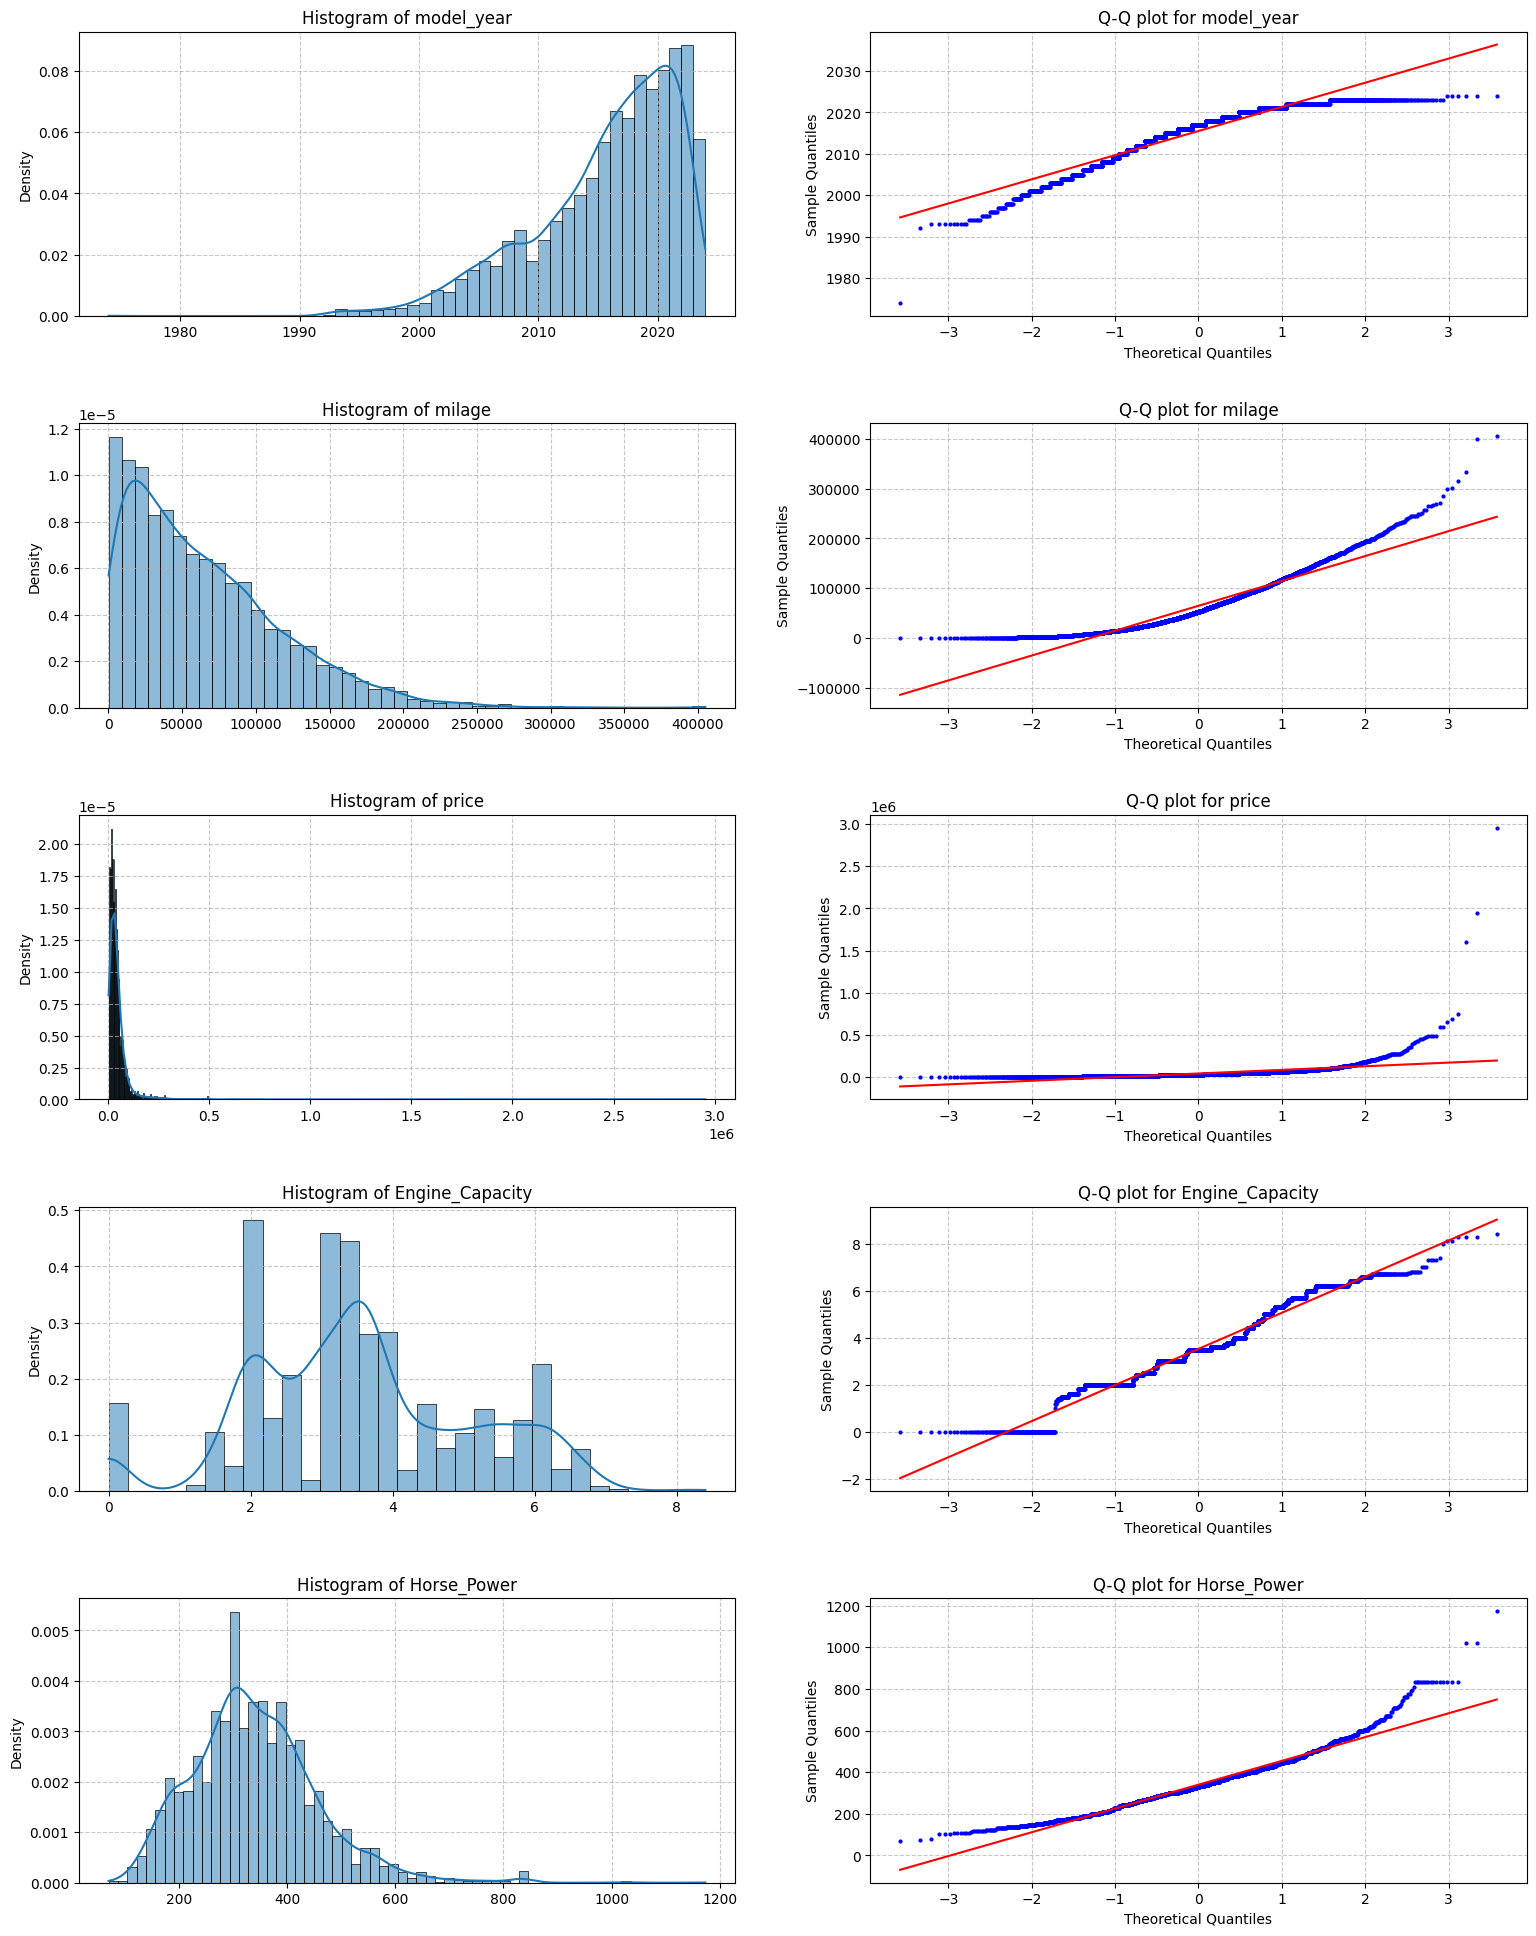

In [65]:
num_cols = len(Numerical_Columns)

fig, axes = plt.subplots(num_cols, 2, figsize=(16, num_cols * 4))

for i, cols in enumerate(Numerical_Columns):
    sns.histplot(df[cols], kde=True, ax=axes[i, 0], stat='density', linewidth=0.5)
    axes[i, 0].set_title(f"Histogram of {cols}")
    axes[i, 0].set_xlabel("")
    axes[i, 0].set_ylabel("Density")
    axes[i, 0].grid(True, linestyle='--', alpha=0.7)

    stats.probplot(df[cols], plot=axes[i, 1], dist='norm', fit=True)
    axes[i, 1].set_title(f'Q-Q plot for {cols}')
    axes[i, 1].get_lines()[0].set_markersize(2.0)
    axes[i, 1].set_xlabel("Theoretical Quantiles")
    axes[i, 1].set_ylabel("Sample Quantiles")
    axes[i, 1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout(pad=3.0)
plt.show()


def testing_Normality(df, col):
    data = df[col].dropna()

    print("=" * 70)
    print(f"Normality Tests for Column: {col}")
    print("-" * 70)

    # Shapiro-Wilk Test
    stat, p = shapiro(data)
    print(f"Shapiro-Wilk test        : stat={stat:.4f}, p={p:.4f}  →  {'Normal' if p > 0.05 else 'Not-Normal'}")

    # Anderson-Darling Test
    value = anderson(data)
    critical_value = value.critical_values[2]
    print(f"Anderson-Darling test    : stat={value.statistic:.4f}, critical={critical_value:.4f}  →  {'Normal' if value.statistic < critical_value else 'Not-Normal'}")

    # Jarque-Bera Test
    jb_stat, jb_p = jarque_bera(data)
    print(f"Jarque-Bera test         : stat={jb_stat:.4f}, p={jb_p:.4f}  →  {'Normal' if jb_p > 0.05 else 'Not-Normal'}")

    # D’Agostino–Pearson Test
    d_stat, d_p = normaltest(data)
    print(f"D’Agostino-Pearson test  : stat={d_stat:.4f}, p={d_p:.4f}  →  {'Normal' if d_p > 0.05 else 'Not-Normal'}")

    # Kolmogorov–Smirnov Test
    ks_stat, ks_p = kstest(data, 'norm', args=(data.mean(), data.std()))
    print(f"K-S test                : stat={ks_stat:.4f}, p={ks_p:.4f}  →  {'Normal' if ks_p > 0.05 else 'Not-Normal'}")

    # Lilliefors Test
    l_stat, l_p = lilliefors(data)
    print(f"Lilliefors test          : stat={l_stat:.4f}, p={l_p:.4f}  →  {'Normal' if l_p > 0.05 else 'Not-Normal'}")

    print("\n")


for col in Numerical_Columns:
    testing_Normality(df, col)

def detect_outliers_using_iqr(data):
    outlier_mask = pd.Series(index=data.columns, dtype=bool)
    
    for col in data.columns:
        if col in Numerical_Columns:
            Q1 = data[col].quantile(0.25)
            Q3 = data[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            
            # Fixed bitwise OR logic for the mask
            col_outliers_mask = (data[col] < lower_bound) | (data[col] > upper_bound)
            outlier_mask[col] = col_outliers_mask.any()
            
    return outlier_mask

# Output results
outliers_iqr_mask = detect_outliers_using_iqr(df)
print("\nOutliers detected using IQR is:\n")
for col, is_outlier in outliers_iqr_mask.items():
    print(f'{col} : {is_outlier}')

def detect_outliers_using_iqr(data):
    outlier_mask=pd.Series(index=data.columns,dtype=bool)

    for col in data.columns:
        if col in Numerical_Columns:
            Q1=data[col].quantile(0.25)
            Q3=data[col].quantile(0.75)
            IQR=Q3-Q1
            lower_bound=Q1-1.5*IQR
            upper_bound=Q3+1.5*IQR
            col_outliers_mask=(
                (data[col]<lower_bound)|(data[col]>upper_bound)
            )
            outlier_mask[col]=col_outliers_mask.any()
    return outlier_mask

outliers_iqr_mask=detect_outliers_using_iqr(df)
print("\nOutliers detected using IQR is:\n")
for col,is_outlier in outliers_iqr_mask.items():
    print(f'{col} : {is_outlier}')

Functions to remove outliers using IOR method

def remove_outliers_iqr(data,Numerical_Columns):
    cleaned_data=data.copy()
    
    for col in Numerical_Columns:
        Q1=cleaned_data[col].quantile(0.25)
        Q3=cleaned_data[col].quantile(0.75)
        IQR=Q3-Q1
        lower_bound=Q1-1.5*IQR
        upper_bound=Q3+1.5*IQR
        cleaned_data=cleaned_data[
        (cleaned_data[col]>=lower_bound)&
        (cleaned_data[col]<=upper_bound)
    ]

    return cleaned_data

cleaned_data_iqr=remove_outliers_iqr(df,Numerical_Columns)
print("DataFrame after removing Outliers using IQR Method:")
print(cleaned_data_iqr)

fig,axes=plt.subplots(1,len(Numerical_Columns),figsize=(18,10))

for i, cols in enumerate(Numerical_Columns):
    axes[i].boxplot(cleaned_data_iqr[cols].dropna())
    axes[i].set_title(cols)
    axes[i].set_ylabel("Values")

plt.suptitle("Boxplots of the Numerical Columns",fontsize=14)
plt.tight_layout(rect=[0,0,1,0.97])
plt.show()

Function to remove outliers using z-score method

## encoding for the machine learning

Numerical_Columns = df.select_dtypes(include=['number']).columns

scaler = StandardScaler()

data_scaled = df.copy()
data_scaled[Numerical_Columns] = scaler.fit_transform(df[Numerical_Columns])

data_scaled[Numerical_Columns].head()


Numerical_Columns = df.select_dtypes(include=['number']).columns

scaler = StandardScaler()

data_scaled = df.copy()
data_scaled[Numerical_Columns] = scaler.fit_transform(df[Numerical_Columns])

data_scaled[Numerical_Columns].head()



scaler = MinMaxScaler()

data_scaled = df.copy()
data_scaled[Numerical_Columns] = scaler.fit_transform(df[Numerical_Columns])

data_scaled[Numerical_Columns].head()

scaler = RobustScaler()

data_scaled = df.copy()
data_scaled[Numerical_Columns] = scaler.fit_transform(df[Numerical_Columns])

data_scaled[Numerical_Columns].head()

In [66]:
df.drop(columns=['engine'], inplace=True, errors='ignore')

LabelEncoder
OneHotEncoder
nominal Encoder
binary encoding
OrdinalEncoder
dummy encoding
mean encoding
cound encoding
frequency endoning
loo encoding
hash enoding
probability encoding
helmert encoding 
contrast encoding
embedding encoding
linear regression with ols method
cost function
and minimization

regularization methods in the linear regression and gradinet descent learning with learning rate as alpha as the parameters


df['ext_col'].value_counts()

#import category_encoders as ce

df1 = df.copy()

# Brand Frequency encoders
brand_freq = df1['brand'].value_counts(normalize=True)
df1['brand'] = df1['brand'].map(brand_freq)


df1.head()

In [67]:
data=df.to_csv('../data/processed/Processed_Data.csv')

In [68]:
data=pd.read_csv('../data/processed/Processed_data.csv')

In [69]:
X=data.drop(columns=['price'])
y=data['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape


num_cols=X.select_dtypes(include=['int64','float64','number']).columns
cat_cols=X.select_dtypes(include=['category','object']).columns

freq_cols = ['brand']
hash_cols = ['model']

onehot_cols = list(set(cat_cols) - set(freq_cols) - set(hash_cols))


X_train_fe=X_train.copy()
X_test_fe=X_test.copy()


for col in freq_cols:
    freq_map=X_train[col].value_counts(normalize=True)
    X_train_fe[col]=X_train[col].map(freq_map)
    X_test_fe[col]=X_test[col].map(freq_map)

X_train_fe[freq_cols] = X_train_fe[freq_cols].fillna(0)
X_test_fe[freq_cols] = X_test_fe[freq_cols].fillna(0)



def hash_encode(Series, n_features=8):
    hasher = FeatureHasher(n_features=n_features, input_type='string')
    return hasher.transform([[x] for x in Series.astype(str)]).toarray()

X_train_hash=np.hstack([hash_encode(X_train[col]) for col in hash_cols])
X_test_hash=np.hstack([hash_encode(X_test[col]) for col in hash_cols])

preprocessor=ColumnTransformer(
    transformers=[
        ('num',StandardScaler(),num_cols),
        ('oneshot',OneHotEncoder(handle_unknown='ignore',drop='first'),onehot_cols)
    ]
)


X_train_hash = np.hstack([hash_encode(X_train[col]) for col in hash_cols])
X_test_hash = np.hstack([hash_encode(X_test[col]) for col in hash_cols])

X_train_base = preprocessor.fit_transform(X_train_fe)
X_test_base = preprocessor.transform(X_test_fe)

X_train_final = np.hstack([X_train_base, X_train_hash])
X_test_final = np.hstack([X_test_base, X_test_hash])

## important

In [70]:
class FrequencyEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, columns):
        self.columns=columns
        self.map ={}
    def fit(self,X,y=None):
        X=pd.DataFrame(X).copy()
        for col in self.columns:
            self.map[col]=X[col].value_counts(normalize=True)
        return self
    def transform(self,X):
        X=pd.DataFrame(X).copy()
        for col in self.columns:
            X[col]=X[col].map(self.maps[col].fillna(0))
        return X[self.columns].values



In [71]:
class HashEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, column, n_features=8):
        self.column=column
        self.n_features=n_features
        self.hasher=FeatureHasher(n_features=n_features, input_type="string")
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X=pd.DataFrame(X)
        tokens=[[str(p)] for p in X[self.columns]]
        return self.hasher.tranform(tokens)

In [72]:
X=data.drop(columns=['price'])
y=data['price']

num_cols=X.select_dtypes(include=['number']).columns
cat_cols=X.select_dtypes(exclude=['number']).columns

freq_cols=['brand']
hash_cols=['model']

onehot_cols=list(set(cat_cols)-set(freq_cols)-set(hash_cols))

In [73]:
preprocessor=ColumnTransformer([
    ('num',StandardScaler(),num_cols),
    ('onehot',OneHotEncoder(),cat_cols),
    ('freq',FrequencyEncoder(freq_cols),freq_cols),
    ('hash',HashEncoder('model',n_features=16),['models'])
])

In [74]:
target_col = 'price'

X = data.drop(columns=[target_col])
y = data[target_col]

num_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = X.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical columns are :", num_cols)
print("Categorical columns are :", cat_cols)



Numerical columns are : ['Unnamed: 0', 'model_year', 'milage', 'Engine_Capacity', 'Horse_Power', 'Engine_Capacity_Missing']
Categorical columns are : ['brand', 'model', 'fuel_type', 'transmission', 'ext_col', 'int_col', 'clean_title', 'Accident_occured']


In [75]:
low_card_cols = [a for a in cat_cols if X[a].nunique() <= 10]
mid_card_cols = [a for a in cat_cols if 10 < X[a].nunique() <= 50]
high_card_cols = [a for a in cat_cols if X[a].nunique() > 50]

print("Low Cardinality Columns:", low_card_cols)
print("Medium Cardinality Columns:", mid_card_cols)
print("High Cardinality Columns:", high_card_cols)


Low Cardinality Columns: ['fuel_type', 'clean_title', 'Accident_occured']
Medium Cardinality Columns: []
High Cardinality Columns: ['brand', 'model', 'transmission', 'ext_col', 'int_col']


In [76]:
df.head()

,brand,model,model_year,milage,fuel_type,transmission,ext_col,int_col,clean_title,price,Engine_Capacity,Horse_Power,Accident_occured,Engine_Capacity_Missing
0,Ford,Utility Police Interceptor Base,2013,51000.0,E85 Flex Fuel,6-Speed A/T,Black,Black,Yes,10300.0,3.7,300.000000,Yes,0
1,Hyundai,Palisade SEL,2021,34742.0,Gasoline,8-Speed Automatic,Moonlight Cloud,Gray,Yes,38005.0,3.8,386.196279,Yes,0
2,Lexus,RX 350 RX 350,2022,22372.0,Gasoline,Automatic,Blue,Black,unknown,54598.0,3.5,392.446701,No,0
3,INFINITI,Q50 Hybrid Sport,2015,88900.0,Hybrid,7-Speed A/T,Black,Black,Yes,15500.0,3.5,354.000000,No,0
4,Audi,Q3 45 S line Premium Plus,2021,9835.0,Gasoline,8-Speed Automatic,Glacier White Metallic,Black,unknown,34999.0,2.0,334.561453,No,0


X_encoding = X.copy()

for col in high_card_cols:
    frequency = X_encoding[col].value_counts(normalize=True)
    X_encoding[col] = X_encoding[col].map(frequency)

num_cols_extended = num_cols + high_card_cols
print("Numerical Columns Extended are :", num_cols_extended)



X_encoding

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols_extended),
        ('low_cat', OneHotEncoder(handle_unknown='ignore'), low_card_cols),
        ('mid_cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), mid_card_cols)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(X_encoding, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

baseline_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

baseline_model.fit(X_train, y_train)

def evaluate(model, x_tr, y_tr, x_te, y_te):
    training_pred = model.predict(x_tr)
    testing_pred = model.predict(x_te)

    print("\n Training Metrics \n")
    print("MAE: ", mean_absolute_error(y_tr, training_pred))
    print("RMSE: ", root_mean_squared_error(y_tr, training_pred))
    print("R2_Score: ", r2_score(y_tr, training_pred))

    print("\n Testing Metrics \n")
    print("MAE: ", mean_absolute_error(y_te, testing_pred))
    print("RMSE: ", root_mean_squared_error(y_te, testing_pred))
    print("R2_Score: ", r2_score(y_te, testing_pred))

evaluate(baseline_model, X_train, y_train, X_test, y_test)

## data leakage

In [77]:
target_cols='price'
X=data.drop(columns=[target_cols])
y=data[target_cols]

low=y.quantile(0.01)
high=y.quantile(0.99)

mask=(y>=low)&(y<=high)
X=X[mask]
y=y[mask]

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


In [78]:
num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

low_card_cols = [c for c in cat_cols if X_train[c].nunique() <= 10]
mid_card_cols = [c for c in cat_cols if 10 < X_train[c].nunique() <= 50]
high_card_cols = [c for c in cat_cols if X_train[c].nunique() > 50]

print("Low:", low_card_cols)
print("Mid:", mid_card_cols)
print("High:", high_card_cols)

Low: ['fuel_type', 'clean_title', 'Accident_occured']
Mid: []
High: ['brand', 'model', 'transmission', 'ext_col', 'int_col']


In [79]:

class FrequencyEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, cols):
        self.cols = cols
        self.maps = {}

    def fit(self, X, y=None):
        for col in self.cols:
            # Store the normalized value counts for each column
            self.maps[col] = X[col].value_counts(normalize=True)
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.cols:
            # Map frequencies and fill unseen categories with 0
            X[col] = X[col].map(self.maps[col]).fillna(0)
        return X

In [80]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols + high_card_cols),
        ('low_cat', OneHotEncoder(handle_unknown='ignore'), low_card_cols),
        ('mid_cat', OrdinalEncoder(
            handle_unknown='use_encoded_value', 
            unknown_value=-1
        ), mid_card_cols)
    ]
)

In [81]:
feature_selector = SelectFromModel(Lasso(alpha=0.001))

In [82]:
feature_selector

SelectFromModel(estimator=Lasso(alpha=0.001))

In [83]:


model = Pipeline(steps=[
    ('freq', FrequencyEncoder(high_card_cols)),
    ('preprocessor', preprocessor),
    ('feature_selector', feature_selector),
    ('regressor', TransformedTargetRegressor(
        regressor=Ridge(),
        func=np.log1p,
        inverse_func=np.expm1
    ))
])

In [84]:
param_grid = {
    'regressor__regressor__alpha': [0.001, 0.01, 0.1, 1, 5, 10, 20, 50, 100]
}

grid = GridSearchCV(model, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Best model:", best_model)
print("Best Alpha:", grid.best_params_)

Best model: Pipeline(steps=[('freq',
                 FrequencyEncoder(cols=['brand', 'model', 'transmission',
                                        'ext_col', 'int_col'])),
                ('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Unnamed: 0', 'model_year',
                                                   'milage', 'Engine_Capacity',
                                                   'Horse_Power',
                                                   'Engine_Capacity_Missing',
                                                   'brand', 'model',
                                                   'transmission', 'ext_col',
                                                   'int_col']),
                                                 ('low_cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  [

e:\AI_Projects\Machine_Learning\USED_CARS_PRICE_PREDECTION\env\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.682e+10, tolerance: 3.733e+08
  model = cd_fast.enet_coordinate_descent(


In [85]:
def evaluate(model, X_tr, y_tr, X_te, y_te):
    train_pred = model.predict(X_tr)
    test_pred = model.predict(X_te)
    
    print("\nTRAIN RESULTS")
    print("MAE:", mean_absolute_error(y_tr, train_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_tr, train_pred)))
    print("R2:", r2_score(y_tr, train_pred))
    
    print("\nTEST RESULTS")
    print("MAE:", mean_absolute_error(y_te, test_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_te, test_pred)))
    print("R2:", r2_score(y_te, test_pred))

In [86]:
evaluate(best_model, X_train, y_train, X_test, y_test)


TRAIN RESULTS
MAE: 11949.73083062787
RMSE: 24569.673286818143
R2: 0.4913652600710685

TEST RESULTS
MAE: 12528.664399526919
RMSE: 26108.69178548172
R2: 0.48022514662303184


In [87]:

dt_model = Pipeline(steps=[
    ('freq', FrequencyEncoder(high_card_cols)),
    ('preprocessor', preprocessor),
    ('feature_selector', feature_selector),
    ('regressor', TransformedTargetRegressor(
        regressor=DecisionTreeRegressor(random_state=42),
        func=np.log1p,
        inverse_func=np.expm1
    ))
])
dt_model.fit(X_train,y_train)

e:\AI_Projects\Machine_Learning\USED_CARS_PRICE_PREDECTION\env\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.682e+10, tolerance: 3.733e+08
  model = cd_fast.enet_coordinate_descent(


Pipeline(steps=[('freq',
                 FrequencyEncoder(cols=['brand', 'model', 'transmission',
                                        'ext_col', 'int_col'])),
                ('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Unnamed: 0', 'model_year',
                                                   'milage', 'Engine_Capacity',
                                                   'Horse_Power',
                                                   'Engine_Capacity_Missing',
                                                   'brand', 'model',
                                                   'transmission', 'ext_col',
                                                   'int_col']),
                                                 ('low_cat',
                                                  OneHotEncoder(handle...ignore'),
                                                  ['fuel_type', 'clean_title',
                                                   'Accident_occured']),
                                                 ('mid_cat',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  [])])),
                ('feature_selector',
                 SelectFromModel(estimator=Lasso(alpha=0.001))),
                ('regressor',
                 TransformedTargetRegressor(func=<ufunc 'log1p'>,
                                            inverse_func=<ufunc 'expm1'>,
                                            regressor=DecisionTreeRegressor(random_state=42)))])

In [88]:
def evaluate(model, X_tr, y_tr, X_te, y_te):
    train_pred = model.predict(X_tr)
    test_pred = model.predict(X_te)
    
    print("\nTRAIN RESULTS")
    print("MAE:", mean_absolute_error(y_tr, train_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_tr, train_pred)))
    print("R2:", r2_score(y_tr, train_pred))
    
    print("\nTEST RESULTS")
    print("MAE:", mean_absolute_error(y_te, test_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_te, test_pred)))
    print("R2:", r2_score(y_te, test_pred))

In [89]:
evaluate(dt_model, X_train, y_train, X_test, y_test)


TRAIN RESULTS
MAE: 1.7734857497067563e-11
RMSE: 2.7416353846482396e-11
R2: 1.0

TEST RESULTS
MAE: 12153.430749682339
RMSE: 22343.031424417964
R2: 0.6193470196862072


In [90]:

param_grid = {
    'regressor__regressor__max_depth': [None, 2, 3, 4, 5],
    'regressor__regressor__min_samples_split': [2, 3, 4, 5],
    'regressor__regressor__min_samples_leaf': [1, 2, 3],
    'regressor__regressor__max_features': [None, 'sqrt', 'log2'],
    'regressor__regressor__ccp_alpha': [0.0, 0.001, 0.01, 0.1, 1]
}

In [91]:
grid_search = GridSearchCV(
    estimator=dt_model,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

e:\AI_Projects\Machine_Learning\USED_CARS_PRICE_PREDECTION\env\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.682e+10, tolerance: 3.733e+08
  model = cd_fast.enet_coordinate_descent(


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('freq',
                                        FrequencyEncoder(cols=['brand', 'model',
                                                               'transmission',
                                                               'ext_col',
                                                               'int_col'])),
                                       ('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['Unnamed: '
                                                                          '0',
                                                                          'model_year',
                                                                          'milage',
                                                                          'Engine_Capacity',
                                                                          'Horse_Power',
                                                                          'Engine_Capacity_Missing',
                                                                          'brand',
                                                                          'model',
                                                                          'transmission',
                                                                          'ext_col',
                                                                          'int_col']),
                                                                        (...
                                                                   regressor=DecisionTreeRegressor(random_state=42)))]),
             n_jobs=-1,
             param_grid={'regressor__regressor__ccp_alpha': [0.0, 0.001, 0.01,
                                                             0.1, 1],
                         'regressor__regressor__max_depth': [None, 2, 3, 4, 5],
                         'regressor__regressor__max_features': [None, 'sqrt',
                                                                'log2'],
                         'regressor__regressor__min_samples_leaf': [1, 2, 3],
                         'regressor__regressor__min_samples_split': [2, 3, 4,
                                                                     5]},
             scoring='neg_mean_squared_error')

In [92]:
def evaluate(model, X_tr, y_tr, X_te, y_te):
    train_pred = model.predict(X_tr)
    test_pred = model.predict(X_te)
    
    print("\nTRAIN RESULTS")
    print("MAE:", mean_absolute_error(y_tr, train_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_tr, train_pred)))
    print("R2:", r2_score(y_tr, train_pred))
    
    print("\nTEST RESULTS")
    print("MAE:", mean_absolute_error(y_te, test_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_te, test_pred)))
    print("R2:", r2_score(y_te, test_pred))

In [93]:

evaluate(grid_search.best_estimator_, X_train, y_train, X_test, y_test)


TRAIN RESULTS
MAE: 4252.732783152933
RMSE: 8958.786687467833
R2: 0.9323752537937577

TEST RESULTS
MAE: 12135.495955372986
RMSE: 21495.21729702444
R2: 0.6476869571251469


In [94]:
rf_model = Pipeline(steps=[
    ('freq', FrequencyEncoder(high_card_cols)),
    ('preprocessor', preprocessor),
    ('regressor', TransformedTargetRegressor(
        regressor=RandomForestRegressor(
            n_estimators=400,
            max_depth=None,
            random_state=42,
            n_jobs=-1
        ),
        func=np.log1p,
        inverse_func=np.expm1
    ))
])

rf_model.fit(X_train, y_train)


Pipeline(steps=[('freq',
                 FrequencyEncoder(cols=['brand', 'model', 'transmission',
                                        'ext_col', 'int_col'])),
                ('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Unnamed: 0', 'model_year',
                                                   'milage', 'Engine_Capacity',
                                                   'Horse_Power',
                                                   'Engine_Capacity_Missing',
                                                   'brand', 'model',
                                                   'transmission', 'ext_col',
                                                   'int_col']),
                                                 ('low_cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['fuel_type', 'clean_title',
                                                   'Accident_occured']),
                                                 ('mid_cat',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  [])])),
                ('regressor',
                 TransformedTargetRegressor(func=<ufunc 'log1p'>,
                                            inverse_func=<ufunc 'expm1'>,
                                            regressor=RandomForestRegressor(n_estimators=400,
                                                                            n_jobs=-1,
                                                                            random_state=42)))])

In [95]:
evaluate(rf_model, X_train, y_train, X_test, y_test)



TRAIN RESULTS
MAE: 3155.776181561873
RMSE: 6933.119338090483
R2: 0.9594991062007628

TEST RESULTS
MAE: 8703.305561792242
RMSE: 15686.992373632194
R2: 0.812360437101507


## Random forest

In [96]:
param_grid = {
    'regressor__regressor__n_estimators': [100,200],
    'regressor__regressor__max_depth': [5,10, 20],
    'regressor__regressor__min_samples_split': [2, 5, 10],
    'regressor__regressor__min_samples_leaf': [1, 2, 4],
    'regressor__regressor__max_features': ['sqrt', 'log2']
}

grid = GridSearchCV(
    rf_model,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

best_rf = grid.best_estimator_
print("Best Model:", best_rf)
print("Best Params:", grid.best_params_)





Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Model: Pipeline(steps=[('freq',
                 FrequencyEncoder(cols=['brand', 'model', 'transmission',
                                        'ext_col', 'int_col'])),
                ('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Unnamed: 0', 'model_year',
                                                   'milage', 'Engine_Capacity',
                                                   'Horse_Power',
                                                   'Engine_Capacity_Missing',
                                                   'brand', 'model',
                                                   'transmission', 'ext_col',
                                                   'int_col']),
                                                 ('low_cat',
                                                  OneHotEncoder(handle_unknown

In [97]:
evaluate(best_rf, X_train, y_train, X_test, y_test)


TRAIN RESULTS
MAE: 3596.8878843943767
RMSE: 8311.70637134329
R2: 0.941791334706619

TEST RESULTS
MAE: 9297.831075368475
RMSE: 19053.969627610128
R2: 0.7231681984625825


## XGBOOST

In [98]:
from xgboost import XGBRegressor

In [99]:
xg_model = Pipeline(steps=[
    ('freq', FrequencyEncoder(high_card_cols)),
    ('preprocess', preprocessor),
    ('regressor', TransformedTargetRegressor(
        regressor=XGBRegressor(
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1
        ),
        func=np.log1p,
        inverse_func=np.expm1
    ))
])

xg_model.fit(X_train, y_train)


Pipeline(steps=[('freq',
                 FrequencyEncoder(cols=['brand', 'model', 'transmission',
                                        'ext_col', 'int_col'])),
                ('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Unnamed: 0', 'model_year',
                                                   'milage', 'Engine_Capacity',
                                                   'Horse_Power',
                                                   'Engine_Capacity_Missing',
                                                   'brand', 'model',
                                                   'transmission', 'ext_col',
                                                   'int_col']),
                                                 ('low_cat',
                                                  OneHotEncoder(handle_u...
                                                                   grow_policy=None,
                                                                   importance_type=None,
                                                                   interaction_constraints=None,
                                                                   learning_rate=None,
                                                                   max_bin=None,
                                                                   max_cat_threshold=None,
                                                                   max_cat_to_onehot=None,
                                                                   max_delta_step=None,
                                                                   max_depth=None,
                                                                   max_leaves=None,
                                                                   min_child_weight=None,
                                                                   missing=nan,
                                                                   monotone_constraints=None,
                                                                   multi_strategy=None,
                                                                   n_estimators=None,
                                                                   n_jobs=-1,
                                                                   num_parallel_tree=None,
                                                                   random_state=42, ...)))])

In [100]:
evaluate(xg_model, X_train, y_train, X_test, y_test)


TRAIN RESULTS
MAE: 1840.4987907082175
RMSE: 3176.262913829135
R2: 0.9914995847092393

TEST RESULTS
MAE: 7817.096414762349
RMSE: 13563.61765555876
R2: 0.8597198829134567


In [101]:
param_grid = {
    'regressor__regressor__n_estimators': [200, 500, 1000], 
    'regressor__regressor__learning_rate': [0.01, 0.05, 0.1],
    'regressor__regressor__max_depth': [3, 5, 6],          
    'regressor__regressor__subsample': [0.8, 1.0],
    'regressor__regressor__colsample_bytree': [0.8, 1.0],  
    'regressor__regressor__gamma': [0, 0.1, 0.2]           
}
grid = GridSearchCV(xg_model, param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)

best_rf = grid.best_estimator_
print(f"Best params: {grid.best_params_}")
print(f"Best CV R2: {grid.best_score_:.4f}")

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best params: {'regressor__regressor__colsample_bytree': 1.0, 'regressor__regressor__gamma': 0, 'regressor__regressor__learning_rate': 0.05, 'regressor__regressor__max_depth': 5, 'regressor__regressor__n_estimators': 1000, 'regressor__regressor__subsample': 0.8}
Best CV R2: 0.8564


In [102]:
evaluate(best_rf, X_train, y_train, X_test, y_test)


TRAIN RESULTS
MAE: 1925.5531376533934
RMSE: 3346.3837914340966
R2: 0.9905646339758588

TEST RESULTS
MAE: 7569.472076144576
RMSE: 13119.55415113585
R2: 0.868754870833728


## SAVE THE MODEL

In [103]:
os.makedirs('ML_Models', exist_ok=True)

In [104]:
import joblib
MODEL_PATH=r"E:\AI_Projects\Machine_Learning\USED_CARS_PRICE_PREDECTION\notebooks\ML_MODELS\best_xgboost.pk1"
joblib.dump(xg_model,MODEL_PATH)
print(f"\n Model saved to:{MODEL_PATH}\n")


 Model saved to:E:\AI_Projects\Machine_Learning\USED_CARS_PRICE_PREDECTION\notebooks\ML_MODELS\best_xgboost.pk1

